# Customer Churn - Initial Audit and Baseline Model

This notebook performs the first validation of the raw churn dataset and builds a baseline churn prediction model.

The goal is to:
- understand the dataset structure,
- identify the main data quality issue,
- prepare the data for modeling,
- and establish a first performance benchmark.

## Step 1 - Inspect dataset structure

We start by checking the shape, columns, and data types of the raw dataset.

This helps us answer:
- how many observations and features we have,
- which columns are categorical,
- which columns are numeric,
- and whether any columns have suspicious data types.

This is especially important because machine learning pipelines depend on correct data typing.

In [21]:
import pandas as pd

# Load raw data
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

# Basic inspection
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

df.head()

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The dataset contains 7,043 rows and 21 columns. Most variables are categorical, while `tenure` and `MonthlyCharges` are already numeric.

One important issue appears immediately: `TotalCharges` is stored as text, even though it should be numeric. This suggests a hidden data quality problem that we need to resolve before modeling.

In [22]:
# Check standard missing values
print("Missing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

# Check duplicate customer IDs
print("\nDuplicate customerID values:", df["customerID"].duplicated().sum())

# Check blank-like values in object columns
object_cols = df.select_dtypes(include="object").columns
blank_like_counts = (
    df[object_cols]
    .apply(lambda col: col.astype(str).str.strip().eq("").sum())
    .sort_values(ascending=False)
)

print("\nBlank-like values:")
print(blank_like_counts.head(10))

# Clean data
df_clean = df.copy()

for col in object_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

print("\nMissing values after TotalCharges conversion:")
print(df_clean.isna().sum().sort_values(ascending=False).head(10))

# Drop rows with invalid TotalCharges
rows_before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=["TotalCharges"]).copy()
rows_after = df_clean.shape[0]

print(f"\nRows removed: {rows_before - rows_after}")
print("Clean shape:", df_clean.shape)

Missing values:
customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
dtype: int64

Duplicate customerID values: 0

Blank-like values:
TotalCharges        11
customerID           0
gender               0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
DeviceProtection     0
dtype: int64

Missing values after TotalCharges conversion:
TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
dtype: int64

Rows removed: 11
Clean shape: (7032, 21)


There are no standard missing values and no duplicate customer IDs.

The main issue is in `TotalCharges`, where blank-like text values prevent correct numeric parsing. After converting the column to numeric, a very small number of rows become missing. Since this affects only a negligible part of the dataset, dropping those rows is a reasonable and clean choice.

With that issue resolved, the dataset is ready for model preparation.

In [23]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_clean.drop(columns=["customerID", "Churn"])
y = (df_clean["Churn"] == "Yes").astype(int)

print("X shape:", X.shape)
print("Churn rate:", round(y.mean(), 4))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Separate feature types
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

X shape: (7032, 19)
Churn rate: 0.2658

Train shape: (5625, 19)
Test shape: (1407, 19)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


The target variable is converted into binary format, where churned customers are labeled as 1.

`customerID` is excluded because it is only an identifier and has no predictive value. The train/test split is stratified so that the churn rate remains consistent across both subsets.

At this point, the data is fully ready for a baseline classification pipeline.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Baseline model
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Train
baseline_model.fit(X_train, y_train)

# Evaluate
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7257
Precision: 0.4901
Recall   : 0.7968
F1-score : 0.6069
ROC-AUC  : 0.8351

Confusion matrix:
[[723 310]
 [ 76 298]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



The baseline logistic regression model provides a solid starting point for churn prediction.

Its strongest result is the ROC-AUC score, which shows that the model separates churners from non-churners reasonably well. The recall for churn is also high, meaning the model identifies most of the customers at risk.

The main limitation is precision: many customers flagged as likely churners do not actually churn. This is acceptable for an initial churn model, but it suggests that the next step should focus on improving the balance between churn detection and false alarms.

This baseline model establishes the first benchmark for churn prediction.

The main value of this step is not just the score itself, but the fact that we now have:
- a reproducible preprocessing pipeline,
- a valid train/test evaluation setup,
- and a baseline model that future models can be compared against.

The next step is to improve interpretability and model comparison with a few targeted visualizations and at least one stronger model.

## Exploratory analysis of churn drivers

Before moving to a stronger model, it is useful to inspect a few patterns in the data that are likely related to churn.

The goal of this section is not to perform a full EDA, but to highlight a few business-relevant relationships that help interpret the problem:
- overall churn distribution,
- churn by contract type,
- and the relationship between churn, tenure, and monthly charges.

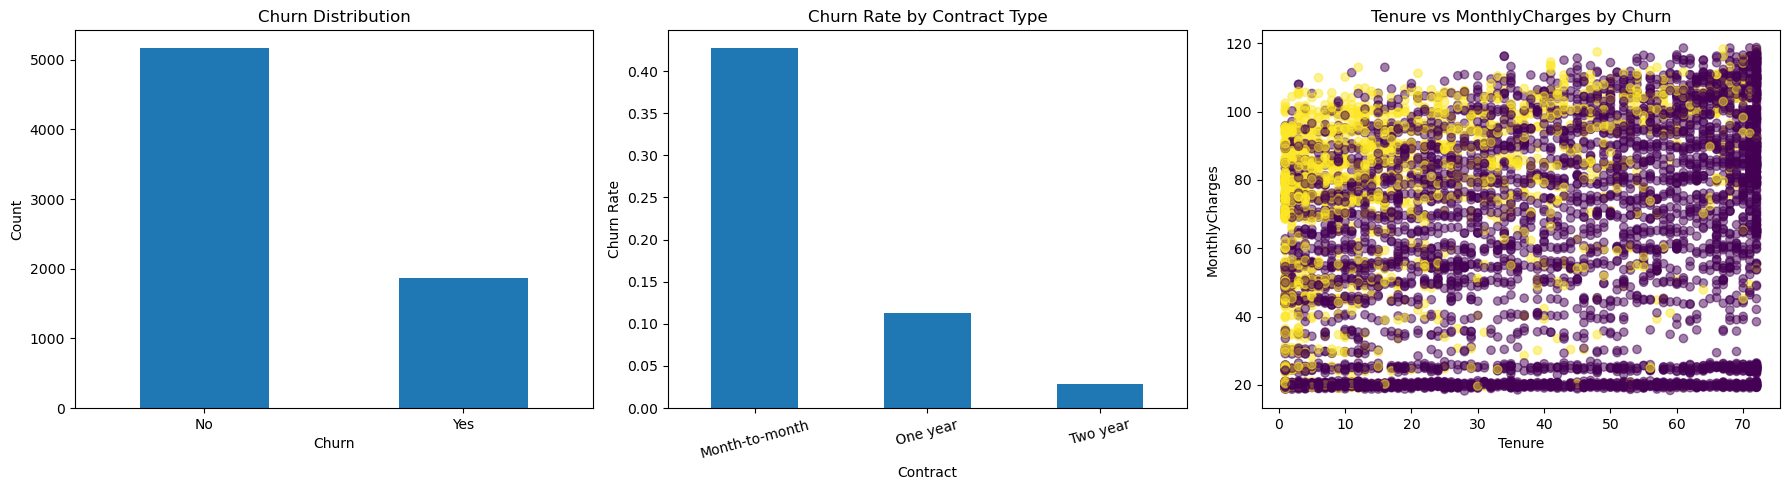

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Churn distribution
df_clean["Churn"].value_counts().plot(kind="bar", ax=axes[0], title="Churn Distribution")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# 2) Churn rate by contract type
contract_churn = pd.crosstab(df_clean["Contract"], df_clean["Churn"], normalize="index")["Yes"]
contract_churn.sort_values(ascending=False).plot(kind="bar", ax=axes[1], title="Churn Rate by Contract Type")
axes[1].set_xlabel("Contract")
axes[1].set_ylabel("Churn Rate")
axes[1].tick_params(axis="x", rotation=15)

# 3) Tenure vs MonthlyCharges colored by churn
churn_map = df_clean["Churn"].map({"No": 0, "Yes": 1})
scatter = axes[2].scatter(
    df_clean["tenure"],
    df_clean["MonthlyCharges"],
    c=churn_map,
    alpha=0.5
)
axes[2].set_title("Tenure vs MonthlyCharges by Churn")
axes[2].set_xlabel("Tenure")
axes[2].set_ylabel("MonthlyCharges")

plt.tight_layout()
plt.show()

The visual analysis supports the baseline modeling results. Churn is not randomly distributed across customers.

Contract type appears to be one of the strongest business drivers: month-to-month customers churn much more frequently than customers with longer contracts. Tenure also shows a clear relationship with churn, with shorter-tenure customers appearing more at risk. Monthly charges seem relevant as well, although their effect is less clear in isolation.

These patterns suggest that the model is learning meaningful customer behavior rather than noise, and they justify moving to a stronger comparison model.

## Summary

In this notebook, the raw churn dataset was inspected and cleaned for initial modeling. The main data quality issue was found in `TotalCharges`, which required conversion to numeric and removal of a small number of invalid rows.

A first baseline logistic regression model was then trained to establish an initial benchmark. The results are promising, but this first pass is not sufficient for a robust modeling pipeline.

The next step is a focused exploratory data analysis to better understand churn patterns, generate business hypotheses, and guide stronger feature engineering and model validation choices.